In [2]:
target_id = 39633275769064365

In [3]:
smoothing = 0

In [47]:
import pymc as pm

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from sparcl.client import SparclClient

In [6]:
from astropy import units as u
from astropy.table import Table
from astropy.modeling import models


In [7]:
import specutils
from specutils import Spectrum1D, SpectralRegion
from specutils.fitting.continuum import fit_continuum
from specutils.manipulation import noise_region_uncertainty, extract_region, gaussian_smooth, box_smooth
from specutils.fitting import find_lines_threshold, estimate_line_parameters, fit_lines, fit_generic_continuum

In [14]:
client = SparclClient()

In [8]:
import desi_utils

In [9]:
dwarf_cat = Table.read("stellar_mass_emline_dwarfs.fits")

In [10]:
spectra_cat = Table.read("spectra_good.fits")

In [11]:
spectra_cat

spectype,redshift_warning,specprimary,specid,sparcl_id,redshift,targetid,survey,program,flux,wavelength
bytes6,int64,bool,int64,bytes36,float64,int64,bytes7,bytes6,float64[7781],float64[7781]
GALAXY,0,True,39627796061886582,0012ece4-8792-11ef-b8c7-525400f334e1,0.0138170471482924,39627796061886582,main,bright,0.9170344471931458 .. 1.1301583051681519,3600.0 .. 9824.000000000524
GALAXY,0,True,39627881336275553,003178a2-87d6-11ef-b1ba-525400f334e1,0.029145176361066498,39627881336275553,main,bright,-1.993598222732544 .. 1.5585238933563232,3600.0 .. 9824.000000000524
GALAXY,0,True,39627673072310922,00f8907c-88bc-11ef-87af-525400f334e1,0.1883229494533152,39627673072310922,main,bright,14.198786735534668 .. 2.5639302730560303,3600.0 .. 9824.000000000524
GALAXY,0,True,39627847324665238,01584025-8839-11ef-baf3-525400f334e1,0.09107665718787228,39627847324665238,main,bright,26.986713409423828 .. 4.269760608673096,3600.0 .. 9824.000000000524
GALAXY,0,True,39627857739124014,01a554f0-86dc-11ef-baf1-525400f334e1,0.02086545542359919,39627857739124014,main,bright,28.703744888305664 .. 2.910529375076294,3600.0 .. 9824.000000000524
GALAXY,0,True,39627767511255158,021ac896-88a4-11ef-bb94-525400f334e1,0.023169001844319696,39627767511255158,main,bright,13.445474624633789 .. 1.4048688411712646,3600.0 .. 9824.000000000524
GALAXY,0,True,39627955936167522,023cf678-878c-11ef-bf88-525400f334e1,0.09142153854307233,39627955936167522,main,bright,10.74429988861084 .. 2.001039505004883,3600.0 .. 9824.000000000524
GALAXY,0,True,39627866882706808,0268d259-893b-11ef-b8a8-525400f334e1,0.027667789526740167,39627866882706808,main,bright,17.092594146728516 .. 1.9699934720993042,3600.0 .. 9824.000000000524
GALAXY,0,True,39633539779528230,02892aa8-8832-11ef-9893-525400f334e1,0.04912460121664657,39633539779528230,main,bright,-7.6255292892456055 .. 1.2866508960723877,3600.0 .. 9824.000000000524


### Retrieve spectrum

In [12]:
idx = np.where(dwarf_cat["targetid"] == target_id)[0][0]

In [15]:
inc = ['specid', 'redshift', 'flux', 'wavelength', 'spectype', 'specprimary', 'survey', 'program', 'targetid', 'redshift_warning']
res = client.retrieve_by_specid(specid_list = [target_id], include = inc,
                                dataset_list = ['DESI-DR1'])


In [16]:
records = res.records

# Select the primary spectrum
spec_primary = np.array([records[jj].specprimary for jj in range(len(records))])

primary_ii = np.where(spec_primary == True)[0][0]



In [17]:
def plot_spectrum(spectrum, **kwargs):
    plt.plot(spectrum.spectral_axis, spectrum.flux, **kwargs)

### Initial plot

In [18]:
meas = dwarf_cat[idx]
meas

xj_sl,target_ra,target_dec,z,zerr,plate_ra,plate_dec,mgii2796_center,mgii2796_centererr,mgii2796_flux,mgii2796_fluxerr,mgii2796_sigma,mgii2796_sigmaerr,mgii2796_cont,mgii2796_conterr,mgii2796_ew,mgii2796_ewerr,mgii2803_center,mgii2803_centererr,mgii2803_flux,mgii2803_fluxerr,mgii2803_sigma,mgii2803_sigmaerr,mgii2803_cont,mgii2803_conterr,mgii2803_ew,mgii2803_ewerr,nev3346_center,nev3346_centererr,nev3346_flux,nev3346_fluxerr,nev3346_sigma,nev3346_sigmaerr,nev3346_cont,nev3346_conterr,nev3346_ew,nev3346_ewerr,nev3426_center,nev3426_centererr,nev3426_flux,nev3426_fluxerr,nev3426_sigma,nev3426_sigmaerr,nev3426_cont,nev3426_conterr,nev3426_ew,nev3426_ewerr,oii3726_center,oii3726_centererr,oii3726_flux,oii3726_fluxerr,oii3726_sigma,oii3726_sigmaerr,oii3726_cont,oii3726_conterr,oii3726_ew,oii3726_ewerr,oii3729_center,oii3729_centererr,oii3729_flux,oii3729_fluxerr,oii3729_sigma,oii3729_sigmaerr,oii3729_cont,oii3729_conterr,oii3729_ew,oii3729_ewerr,neiii3869_center,neiii3869_centererr,neiii3869_flux,neiii3869_fluxerr,neiii3869_sigma,neiii3869_sigmaerr,neiii3869_cont,neiii3869_conterr,neiii3869_ew,neiii3869_ewerr,neiii3967_center,neiii3967_centererr,neiii3967_flux,neiii3967_fluxerr,neiii3967_sigma,neiii3967_sigmaerr,neiii3967_cont,neiii3967_conterr,neiii3967_ew,neiii3967_ewerr,hepsilon_center,hepsilon_centererr,hepsilon_flux,hepsilon_fluxerr,hepsilon_sigma,hepsilon_sigmaerr,hepsilon_cont,hepsilon_conterr,hepsilon_ew,hepsilon_ewerr,hei4026_center,hei4026_centererr,hei4026_flux,hei4026_fluxerr,hei4026_sigma,hei4026_sigmaerr,hei4026_cont,hei4026_conterr,hei4026_ew,hei4026_ewerr,hdelta_center,hdelta_centererr,hdelta_flux,hdelta_fluxerr,hdelta_sigma,hdelta_sigmaerr,hdelta_cont,hdelta_conterr,hdelta_ew,hdelta_ewerr,hgamma_center,hgamma_centererr,hgamma_flux,hgamma_fluxerr,hgamma_sigma,hgamma_sigmaerr,hgamma_cont,hgamma_conterr,hgamma_ew,hgamma_ewerr,oiii4363_center,oiii4363_centererr,oiii4363_flux,oiii4363_fluxerr,oiii4363_sigma,oiii4363_sigmaerr,oiii4363_cont,oiii4363_conterr,oiii4363_ew,oiii4363_ewerr,hei4471_center,hei4471_centererr,hei4471_flux,hei4471_fluxerr,hei4471_sigma,hei4471_sigmaerr,hei4471_cont,hei4471_conterr,hei4471_ew,hei4471_ewerr,heii4686_center,heii4686_centererr,heii4686_flux,heii4686_fluxerr,heii4686_sigma,heii4686_sigmaerr,heii4686_cont,heii4686_conterr,heii4686_ew,heii4686_ewerr,hbeta_center,hbeta_centererr,hbeta_flux,hbeta_fluxerr,hbeta_sigma,hbeta_sigmaerr,hbeta_cont,hbeta_conterr,hbeta_ew,hbeta_ewerr,oiii4959_center,oiii4959_centererr,oiii4959_flux,oiii4959_fluxerr,oiii4959_sigma,oiii4959_sigmaerr,oiii4959_cont,oiii4959_conterr,oiii4959_ew,oiii4959_ewerr,oiii5007_center,oiii5007_centererr,oiii5007_flux,oiii5007_fluxerr,oiii5007_sigma,oiii5007_sigmaerr,oiii5007_cont,oiii5007_conterr,oiii5007_ew,oiii5007_ewerr,nii5755_center,nii5755_centererr,nii5755_flux,nii5755_fluxerr,nii5755_sigma,nii5755_sigmaerr,nii5755_cont,nii5755_conterr,nii5755_ew,nii5755_ewerr,hei5876_center,hei5876_centererr,hei5876_flux,hei5876_fluxerr,hei5876_sigma,hei5876_sigmaerr,hei5876_cont,hei5876_conterr,hei5876_ew,hei5876_ewerr,oi6300_center,oi6300_centererr,oi6300_flux,oi6300_fluxerr,oi6300_sigma,oi6300_sigmaerr,oi6300_cont,oi6300_conterr,oi6300_ew,oi6300_ewerr,siii6312_center,siii6312_centererr,siii6312_flux,siii6312_fluxerr,siii6312_sigma,siii6312_sigmaerr,siii6312_cont,siii6312_conterr,siii6312_ew,siii6312_ewerr,nii6548_center,nii6548_centererr,nii6548_flux,nii6548_fluxerr,nii6548_sigma,nii6548_sigmaerr,nii6548_cont,nii6548_conterr,nii6548_ew,nii6548_ewerr,halpha_center,halpha_centererr,halpha_flux,halpha_fluxerr,halpha_sigma,halpha_sigmaerr,halpha_cont,halpha_conterr,halpha_ew,halpha_ewerr,nii6583_center,nii6583_centererr,nii6583_flux,nii6583_fluxerr,nii6583_sigma,nii6583_sigmaerr,nii6583_cont,nii6583_conterr,nii6583_ew,nii6583_ewerr,sii6716_center,sii6716_centererr,sii6716_flux,sii6716_fluxerr,sii6716_sigma,sii6716_sigmaerr,sii6716_cont,sii6716_conterr,sii6716_ew,sii6716_ewerr,sii6731_center,sii6731_centererr,sii6731_flux,sii6731_fluxerr,sii

In [19]:
z = meas["z"]
z

0.04810157606081316

In [20]:
flux_unit = 1e-17 * u.erg / u.s / u.cm**2 / u.angstrom

In [21]:
λ = records[primary_ii].wavelength / (1 + z)
galspec = Spectrum1D(flux=records[primary_ii].flux * flux_unit, spectral_axis=λ * u.angstrom)

In [22]:
if smoothing == 0:
    smoothspec = galspec
else:
    smoothspec = box_smooth(galspec, smoothing)

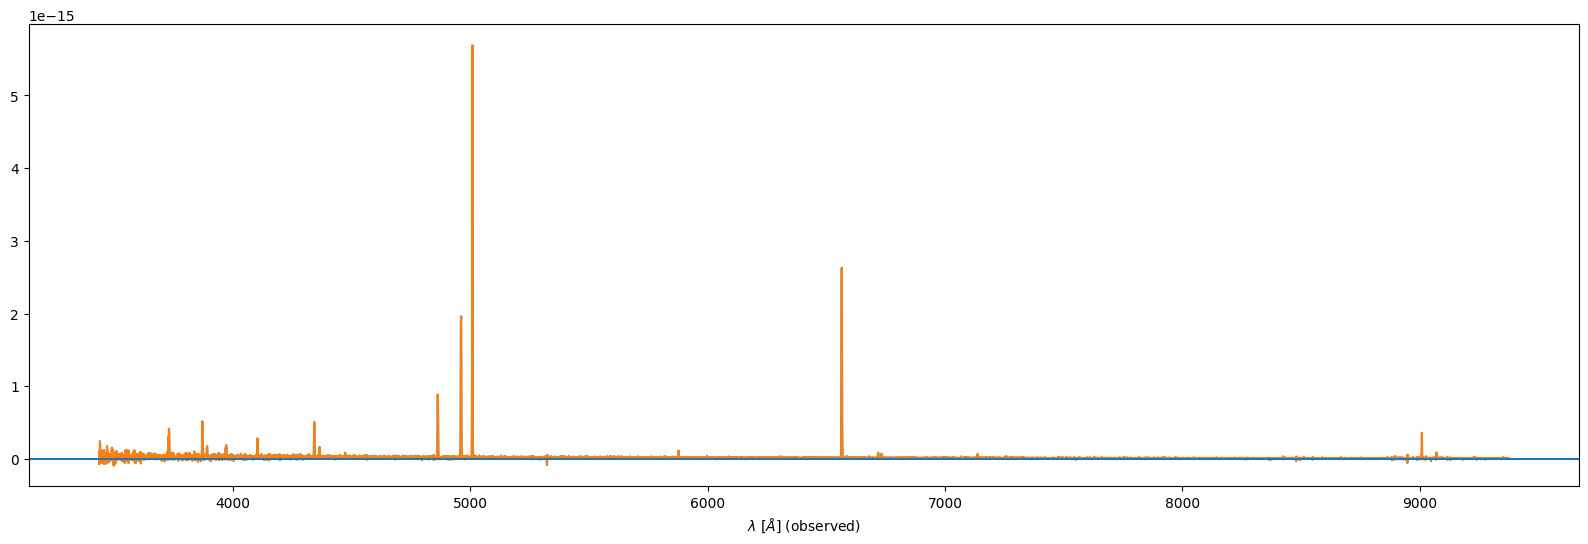

In [23]:


plt.figure(figsize = (20, 6))

# Plot the original spectrum in maroon color
plot_spectrum(galspec)
plot_spectrum(smoothspec)
plt.axhline(0)

plt.xlabel(r'$\lambda$ [$\AA$] (observed)')
plt.show()



In [24]:
good_lines = desi_utils.retrieve_good_lines(meas)
good_lines

/home/jail/dlusers/dboyea/desi_utils.py:88: RuntimeWarning: invalid value encountered in scalar divide
  if galaxy[line + "_flux"] / galaxy[line + "_fluxerr"] > snr_min:


['oii3726',
 'oii3729',
 'neiii3869',
 'neiii3967',
 'hepsilon',
 'hdelta',
 'hgamma',
 'oiii4363',
 'hbeta',
 'oiii4959',
 'oiii5007',
 'hei5876',
 'halpha',
 'sii6716',
 'sii6731',
 'hei7065',
 'ariii7136',
 'ariii7751',
 'siii9071']

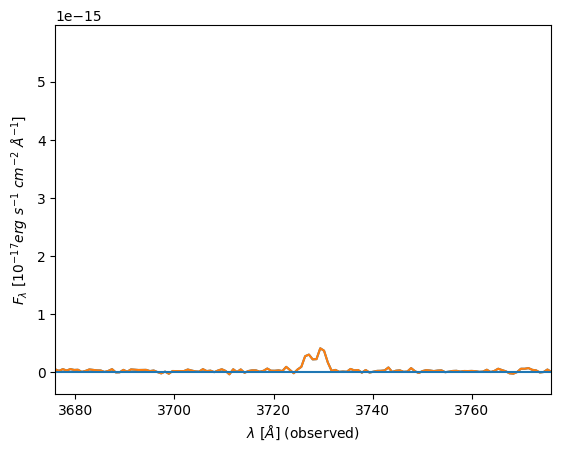

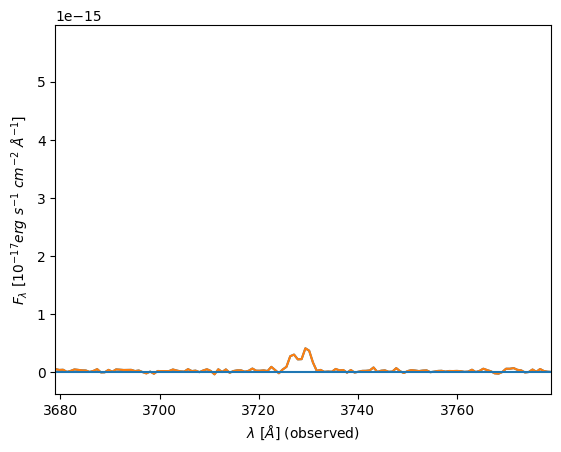

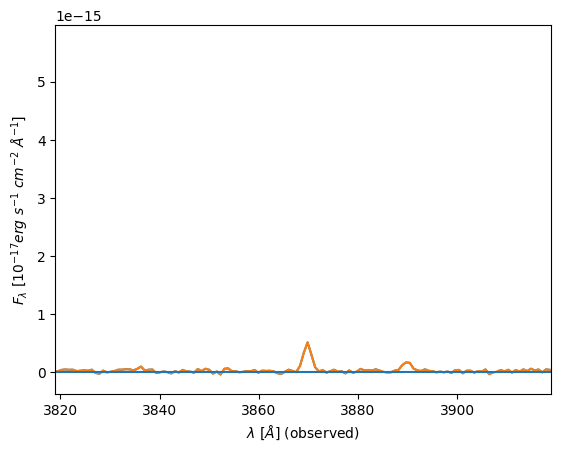

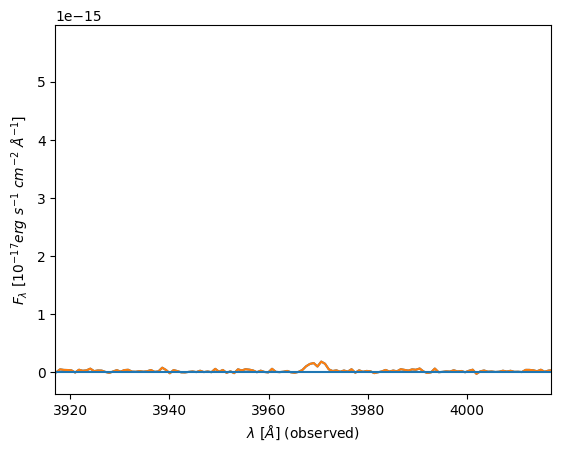

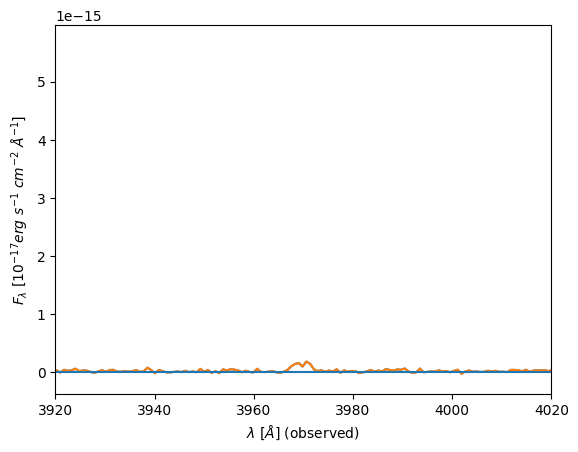

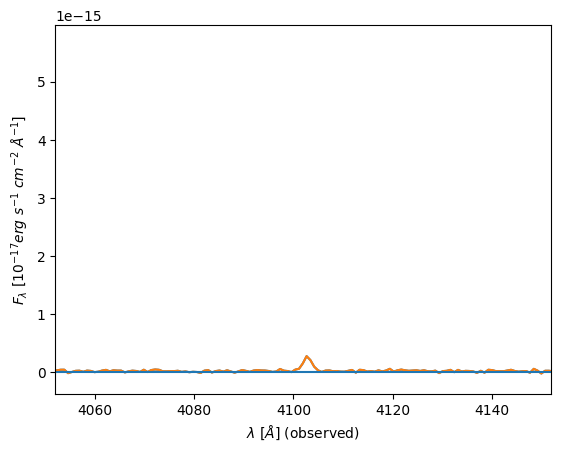

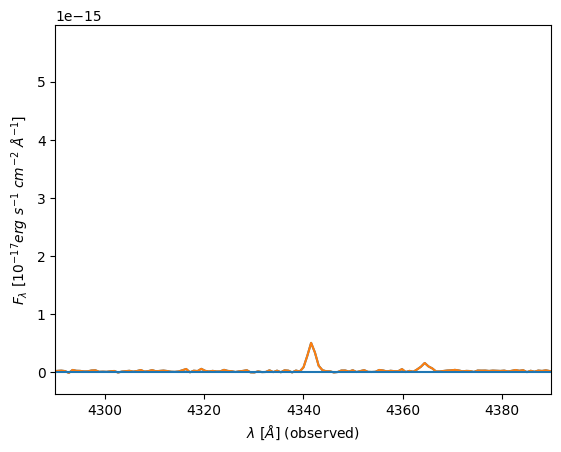

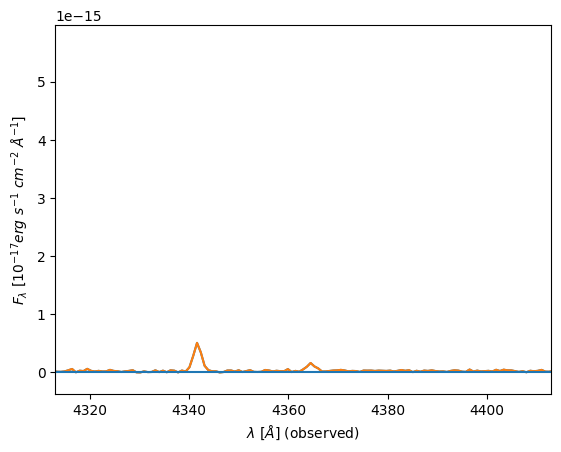

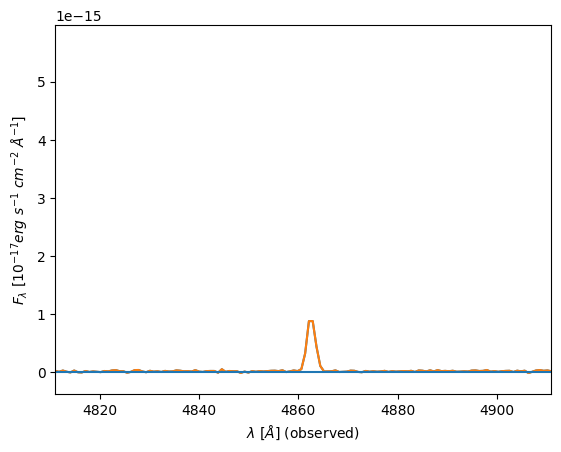

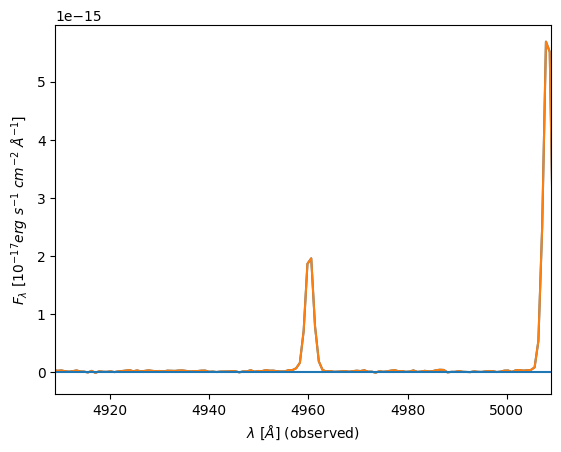

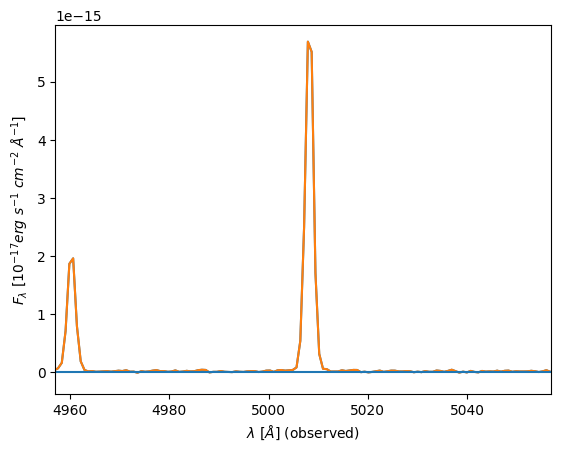

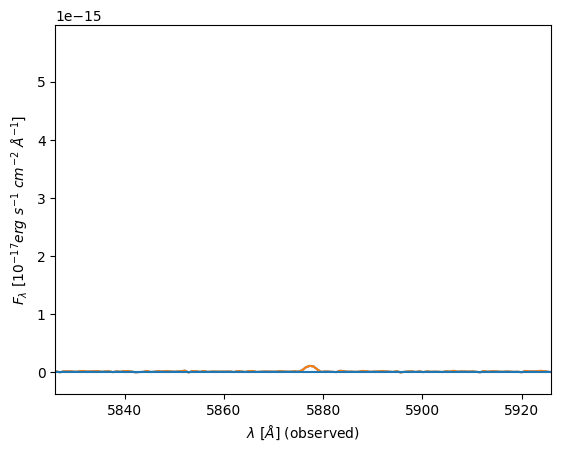

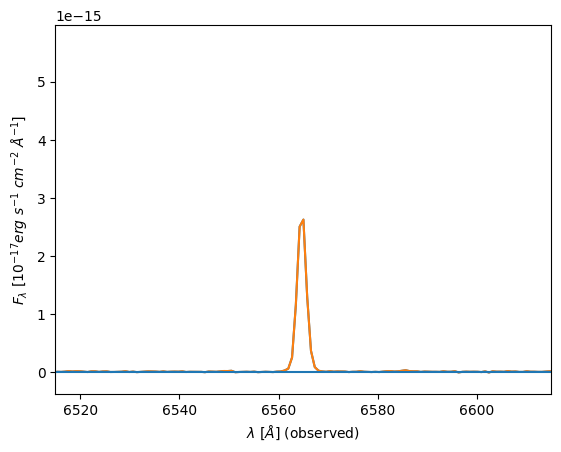

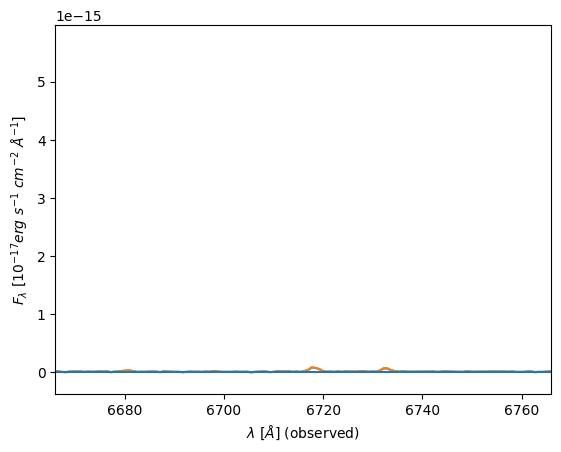

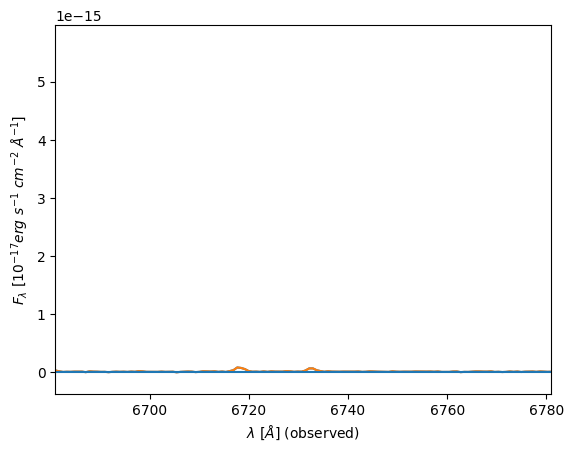

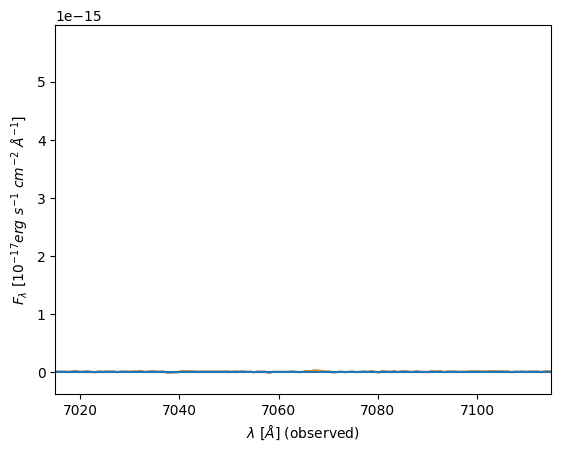

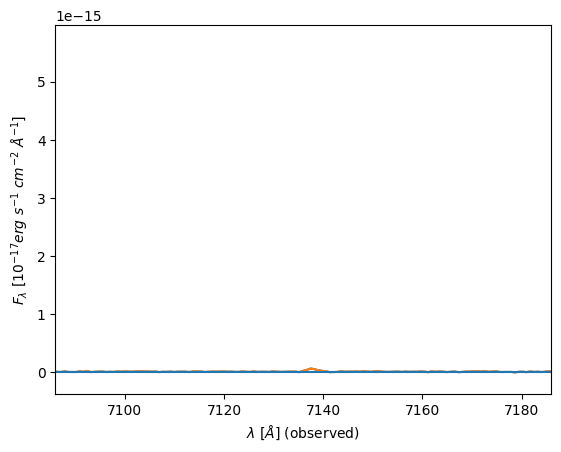

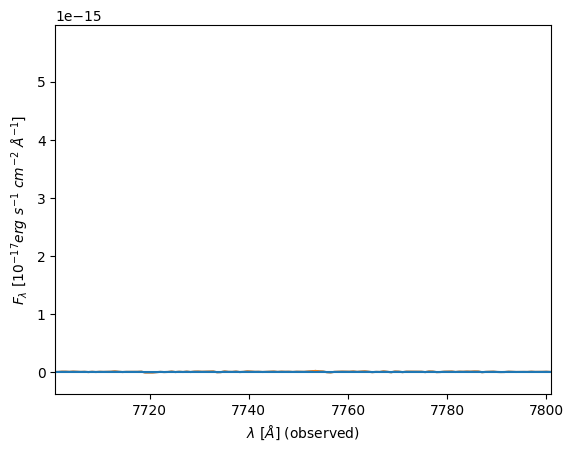

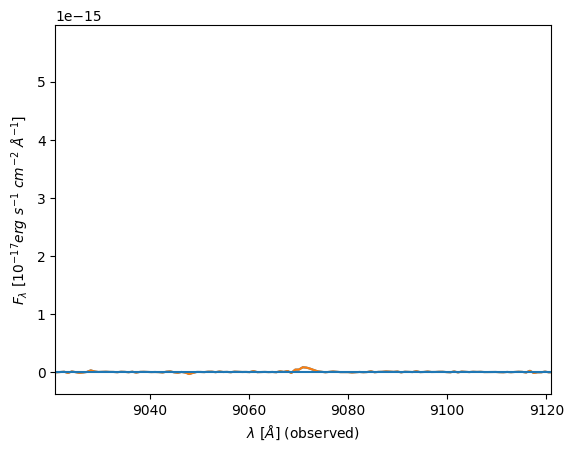

In [25]:
for line in good_lines:
    λ = desi_utils.retrieve_wavelength(line) 

    # Plot the original spectrum in maroon color
    plot_spectrum(galspec)
    
    # Over-plotting smoothed spectra in black 
    plot_spectrum(smoothspec)

    plt.axhline(0)

    plt.xlim(λ - 50, λ+50)
    plt.xlabel(r'$\lambda$ [$\AA$] (observed)')
    plt.ylabel(r'$F_{\lambda}$ [$10^{-17} erg\ s^{-1}\ cm^{-2}\ \AA^{-1}$]')
    plt.show()



# Finding & fitting lines

In [26]:
cont_fit = fit_generic_continuum(smoothspec)

In [27]:
cont_fit

<QuantityModel Chebyshev1D(3, c0=-0., c1=0., c2=-0., c3=0.), input_units=Angstrom, return_units=erg / (Angstrom s cm2)>

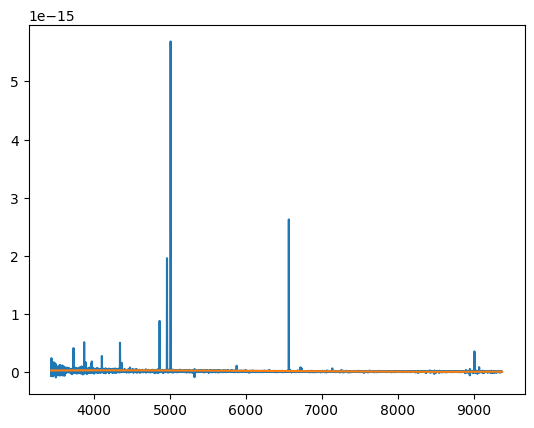

In [50]:
λ = smoothspec.spectral_axis
plt.plot(smoothspec.spectral_axis, smoothspec.flux)
plt.plot(λ, cont_fit(λ))


In [29]:
flat_spec = smoothspec - cont_fit(λ)

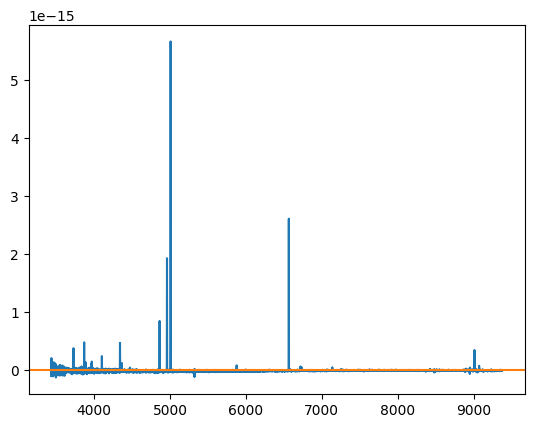

In [30]:
plt.plot(λ, flat_spec.flux)
plt.axhline(0, color="C1")

In [31]:
def contsub(spectrum, lambda1, lambda2, lambda3, lambda4):
    '''
    Calculate the continuum in regions (lambda1, lambda2) and (lambda3, lambda4)
    Subtract the continuum and return a new spectrum for just the range (lambda1, lambda4) 
    '''
    imin = np.where(spectrum.spectral_axis.value > lambda1)[0][0]
    imax = np.where(spectrum.spectral_axis.value < lambda4)[0][-1]
    indxs = np.arange(imin, imax)
    flux = spectrum.flux
    wave = spectrum.spectral_axis
    spec2 = Spectrum1D(flux=flux[indxs], spectral_axis=wave[indxs])
    region = [(lambda1 * u.Angstrom, lambda2 * u.Angstrom), (lambda3 * u.Angstrom, lambda4 * u.Angstrom)]
    fitted_continuum = fit_continuum(spec2, window=region)
    contfit = fitted_continuum(spec2.spectral_axis)
    new_spec = Spectrum1D(flux=spec2.flux-contfit , spectral_axis=spec2.spectral_axis)

    new_spec.uncertainty = noise_region_uncertainty(new_spec, SpectralRegion(region)).uncertainty

    return new_spec


In [32]:
def fitline(spectrum, lambda1, lambda2): 
    '''
    Fit a single emission line that is in the range (lambda1, lambda2) 
    '''
    sub_region = SpectralRegion(lambda1*u.Angstrom, lambda2*u.Angstrom)
    sub_spectrum = extract_region(spectrum, sub_region)
    line  = estimate_line_parameters(sub_spectrum, models.Gaussian1D())
    return line

In [33]:
def fit_all_lines(subspec, line_windows, **kwargs):
    line_ic = []
    for window in line_windows:
        line_fit = fitline(subspec, window[0], window[1])
        if line_fit.mean > window[1]*u.angstrom:
            line_fit.mean = window[1]*u.angstrom
        if line_fit.mean < window[0]*u.angstrom:
            line_fit.mean = window[0]*u.angstrom
            
        line_ic.append(models.Gaussian1D(amplitude=line_fit.amplitude, mean=line_fit.mean, stddev=line_fit.stddev))
        print(line_fit)

    
    full_fit = fit_lines(subspec, line_ic, window=line_windows*u.angstrom)

    return full_fit

In [34]:
def plot_line_models(subspec, line_fits):
    xrange = subspec.spectral_axis[[0, -1]]
    plt.plot(subspec.spectral_axis, subspec.flux, lw=3, color="black")
    plt.fill_between(subspec.spectral_axis.value, subspec.flux.value - subspec.uncertainty.array, subspec.flux.value + subspec.uncertainty.array,
                    alpha = 0.2)
        
    x = np.linspace(xrange[0], xrange[1], 1000)

    for linefit_ob in line_fits:
        model = (linefit_ob(x))
        plt.plot(x, model, alpha=1, lw=2)
    


In [35]:
def print_results(line_fits):
    for fit in line_fits:
        flux = fit.amplitude * fit.stddev * np.sqrt(2*np.pi)

        flux = flux * (1+z) / 1e-17
        μ = fit.mean.value
        print(f"{μ:6.1f}\t{flux:8.4f}")
        

In [52]:
def plot_line_fit(subspec, models, line, width=25):
    λ0 = desi_utils.retrieve_wavelength(line) 
    model_idx = np.argmin([np.abs(model.mean.value - λ0) for model in models])

    model = models[model_idx]

    xrange = (λ0 - width, λ0 + width)
    plot_spectrum(subspec, lw=3, color="black")
    plt.fill_between(subspec.spectral_axis.value, subspec.flux.value - subspec.uncertainty.array, subspec.flux.value + subspec.uncertainty.array,
                    alpha = 0.2, color="black")


    xmodel = np.linspace(*xrange, 1000)
    ymodel = model(xmodel * u.angstrom)
    plt.plot(xmodel, ymodel, alpha=1, lw=2)


    # plot catalogue model
    model_idx = np.argmin([np.abs(model.mean.value - λ0) for model in models])

    model = models[model_idx]

    
    plt.xlim(*xrange)
    plt.title(line)


In [ ]:
def fit_lines(subspec):
    with pm.Model():
        

## MCMC fitting


In [70]:
"""
Multi-line spectral fitting with PyMC
======================================

Fits an arbitrary number of (possibly blended) emission lines in a
continuum-subtracted 1D spectrum using Gaussian profiles and Bayesian
inference (NUTS via PyMC).

Model
-----
flux(wave) = sum_i A_i * exp(-0.5 * ((wave - mu_i) / sigma_i)^2)
             + c0 + c1 * (wave - wave0)      # small residual "continuum" tilt
             + noise

Each line gets:
    A_i     : amplitude (HalfNormal, must be positive -> emission line)
    mu_i    : line center (Normal, tightly centered on your guess)
    sigma_i : Gaussian width (HalfNormal, bounded away from 0)

The residual continuum term (c0, c1) absorbs small imperfections from
continuum subtraction so they don't bias the line amplitudes/widths.
Set `fit_continuum=False` to drop it if you trust your continuum fully.

Usage
-----
    result = fit_lines(
        wave, flux, flux_err,
        line_centers=[6548.05, 6562.82, 6583.45],   # [NII], Halpha, [NII]
        line_names=["NII_6548", "Halpha", "NII_6584"],
    )
    result.summary()
    result.plot_fit()
    result.plot_corner()
"""

from __future__ import annotations

from dataclasses import dataclass, field
from typing import Sequence

import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import pytensor.tensor as pt
import arviz as az


@dataclass
class LineFitResult:
    trace: az.InferenceData
    model: pm.Model
    wave: np.ndarray
    flux: np.ndarray
    flux_err: np.ndarray
    line_names: list
    fit_continuum: bool

    def summary(self, var_names=None):
        """Return an arviz summary table of the posterior."""
        if var_names is None:
            var_names = ["amp", "mu", "sigma"] + (
                ["c0", "c1"] if self.fit_continuum else []
            )
        return az.summary(self.trace, var_names=var_names)

    def best_fit_curve(self, wave=None, hdi=True):
        """
        Return the posterior-mean model spectrum (and optionally the 94% HDI)
        evaluated on `wave` (defaults to the fitted wavelength grid).
        """
        if wave is None:
            wave = self.wave
        posterior = self.trace.posterior
        if hasattr(posterior, "to_dataset"):
            posterior = posterior.to_dataset()
        post = posterior.stack(sample=("chain", "draw"))
        amp = post["amp"].values      # (n_lines, n_samples)
        mu = post["mu"].values
        sigma = post["sigma"].values
        n_lines, n_samples = amp.shape

        w = wave[:, None, None]                       # (n_wave,1,1)
        a = amp[None, :, :]                            # (1,n_lines,n_samples)
        m = mu[None, :, :]
        s = sigma[None, :, :]
        lines = a * np.exp(-0.5 * ((w - m) / s) ** 2)  # (n_wave,n_lines,n_samples)
        model_samples = lines.sum(axis=1)              # (n_wave, n_samples)

        if self.fit_continuum:
            c0 = post["c0"].values[None, :]
            c1 = post["c1"].values[None, :]
            wave0 = self.wave.mean()
            model_samples = model_samples + c0 + c1 * (w[:, 0, :] - wave0)

        mean = model_samples.mean(axis=1)
        if not hdi:
            return mean, None, None
        lo = np.percentile(model_samples, 3, axis=1)
        hi = np.percentile(model_samples, 97, axis=1)
        return mean, lo, hi

    def plot_fit(self, ax=None, show_components=True):
        if ax is None:
            fig, ax = plt.subplots(figsize=(9, 5))

        ax.errorbar(
            self.wave, self.flux, yerr=self.flux_err,
            fmt=".", color="k", ms=6, alpha=1, label="data", zorder=1,
        )

        mean, lo, hi = self.best_fit_curve()
        ax.plot(self.wave, mean, color="crimson", lw=2, label="total fit", zorder=3)
        ax.fill_between(self.wave, lo, hi, color="crimson", alpha=0.2, zorder=2)

        if show_components:
            posterior = self.trace.posterior
            if hasattr(posterior, "to_dataset"):
                posterior = posterior.to_dataset()
            post_mean = posterior.mean(dim=("chain", "draw"))
            amp = post_mean["amp"].values
            mu = post_mean["mu"].values
            sigma = post_mean["sigma"].values
            for i, name in enumerate(self.line_names):
                comp = amp[i] * np.exp(-0.5 * ((self.wave - mu[i]) / sigma[i]) ** 2)
                if self.fit_continuum:
                    c0 = float(post_mean["c0"].values)
                    c1 = float(post_mean["c1"].values)
                    wave0 = self.wave.mean()
                    comp = comp + c0 + c1 * (self.wave - wave0)
                ax.plot(self.wave, comp, "--", lw=1.3, label=name, zorder=2)

        ax.set_xlabel("Wavelength")
        ax.set_ylabel("Flux")
        ax.legend(fontsize=8)
        return ax

    def plot_corner(self, var_names=None):
        if var_names is None:
            var_names = ["amp", "mu", "sigma"]
        return az.plot_pair(
            self.trace, var_names=var_names, kind="kde",
            marginals=True, figsize=(9, 9),
        )

    def line_fluxes(self):
        """
        Integrated flux of each Gaussian line: A * sigma * sqrt(2*pi),
        with uncertainty, computed from the posterior samples.
        """
        post = self.trace.posterior
        if hasattr(post, "to_dataset"):
            post = post.to_dataset()
        # amp and sigma are separate RVs with independent xarray dims even
        # though they share a shape, so multiply on the underlying arrays
        # (chain, draw, line) rather than via xarray broadcasting.
        amp_vals = post["amp"].values
        sigma_vals = post["sigma"].values
        integrated_vals = amp_vals * sigma_vals * np.sqrt(2 * np.pi)

        integrated = post["amp"].copy(data=integrated_vals)
        integrated = integrated.rename("integrated_flux").rename(
            {"amp_dim_0": "line"}
        )
        integrated = integrated.assign_coords(line=self.line_names)
        summ = az.summary(integrated)
        return summ


def fit_lines(
    wave: np.ndarray,
    flux: np.ndarray,
    flux_err: np.ndarray | float | None,
    line_centers: Sequence[float],
    line_names: Sequence[str] | None = None,
    amp_guess: Sequence[float] | None = None,
    sigma_guess: Sequence[float] | float | None = None,
    center_prior_width: float = 2.0,
    sigma_bounds: tuple[float, float] = (0.3, 15.0),
    fit_continuum: bool = True,
    draws: int = 2000,
    tune: int = 2000,
    chains: int = 4,
    cores: int = 1,
    target_accept: float = 0.9,
    random_seed: int = 42,
) -> LineFitResult:
    """
    Fit `n = len(line_centers)` Gaussian emission lines simultaneously.

    Parameters
    ----------
    wave, flux : 1D arrays
        Continuum-subtracted spectrum (same units for wave as line_centers).
    flux_err : 1D array, scalar, or None
        Per-pixel flux uncertainty. If None, a single noise scale is fit
        from the data (HalfNormal prior).
    line_centers : list of float
        Initial guesses for each line's central wavelength.
    line_names : list of str, optional
        Labels for output (defaults to Line_0, Line_1, ...).
    amp_guess : list of float, optional
        Initial amplitude guesses (defaults to max(flux) near each line).
    sigma_guess : list of float or float, optional
        Initial guess for line widths (defaults to ~3x median pixel spacing).
    center_prior_width : float
        Std dev (in wavelength units) of the Normal prior on each mu,
        centered at the corresponding line_centers entry. Keep this tight
        enough to prevent lines from swapping identities when blended.
    sigma_bounds : (low, high)
        Bounds used to build a bounded HalfNormal-like prior on sigma so it
        can't collapse to 0 or blow up across the whole window.
    fit_continuum : bool
        If True, fit a small linear residual continuum (c0 + c1*(wave-wave0)).
    draws, tune, chains, target_accept : PyMC sampling controls.

    Returns
    -------
    LineFitResult
    """
    wave = np.asarray(wave, dtype=float)
    flux = np.asarray(flux, dtype=float)
    n_lines = len(line_centers)
    line_centers = np.asarray(line_centers, dtype=float)

    if line_names is None:
        line_names = [f"Line_{i}" for i in range(n_lines)]

    dw = np.median(np.diff(np.sort(wave)))
    if sigma_guess is None:
        sigma_guess = np.full(n_lines, 3 * dw)
    elif np.isscalar(sigma_guess):
        sigma_guess = np.full(n_lines, sigma_guess)
    sigma_guess = np.asarray(sigma_guess, dtype=float)

    if amp_guess is None:
        amp_guess = []
        for c in line_centers:
            mask = np.abs(wave - c) < 5 * dw
            amp_guess.append(flux[mask].max() if mask.any() else flux.max())
    amp_guess = np.asarray(amp_guess, dtype=float)
    amp_guess = np.clip(amp_guess, 1e-6, None)

    known_err = flux_err is not None
    if known_err and np.isscalar(flux_err):
        flux_err = np.full_like(flux, float(flux_err))

    wave0 = wave.mean()
    sigma_lo, sigma_hi = sigma_bounds

    with pm.Model() as model:
        wave_data = pm.Data("wave_data", wave)

        amp = pm.Normal("amp", sigma=amp_guess * 3, shape=n_lines,
                             initval=amp_guess)
        mu = pm.Normal("mu", mu=line_centers, sigma=center_prior_width,
                        shape=n_lines, initval=line_centers)
        # Bounded width: HalfNormal truncated to [sigma_lo, sigma_hi]
        sigma_raw = pm.HalfNormal("sigma_raw", sigma=sigma_guess, shape=n_lines,
                                   initval=sigma_guess)
        sigma = pm.Deterministic(
            "sigma", pt.clip(sigma_raw, sigma_lo, sigma_hi)
        )

        # (n_wave, n_lines) broadcast
        lines = amp[None, :] * pt.exp(
            -0.5 * ((wave_data[:, None] - mu[None, :]) / sigma[None, :]) ** 2
        )
        model_flux = lines.sum(axis=1)

        if fit_continuum:
            c0 = pm.Normal("c0", mu=0.0, sigma=np.nanstd(flux))
            c1 = pm.Normal("c1", mu=0.0, sigma=np.nanstd(flux) / max(np.ptp(wave), 1))
            model_flux = model_flux + c0 + c1 * (wave_data - wave0)

        pm.Deterministic("model_flux", model_flux)

        if known_err:
            pm.Normal("obs", mu=model_flux, sigma=flux_err, observed=flux)
        else:
            noise = pm.HalfNormal("noise", sigma=np.nanstd(flux))
            pm.Normal("obs", mu=model_flux, sigma=noise, observed=flux)

        trace = pm.sample(
            draws=draws, tune=tune, chains=chains, cores=cores,
            target_accept=target_accept, random_seed=random_seed,
            progressbar=True,
        )

    return LineFitResult(
        trace=trace, model=model, wave=wave, flux=flux,
        flux_err=flux_err if known_err else np.full_like(flux, np.nan),
        line_names=list(line_names), fit_continuum=fit_continuum,
    )



## Halpha

In [57]:
region = (6000, 6400, 6800, 7000)

In [58]:
subspec = contsub(flat_spec, *region)

In [59]:
line_centers = [6563, 6583, 6716]
line_names = ["halpha", "nii6583", "sii6716"]

In [72]:
result = fit_lines(
    subspec.spectral_axis, subspec.flux * 1e17, None,
    line_centers=line_centers,
    line_names=line_names,
    draws=1000, tune=1000, chains=2,   # quick demo settings
)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [amp, mu, sigma_raw, c0, c1, noise]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 19 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics


<Axes: xlabel='Wavelength', ylabel='Flux'>

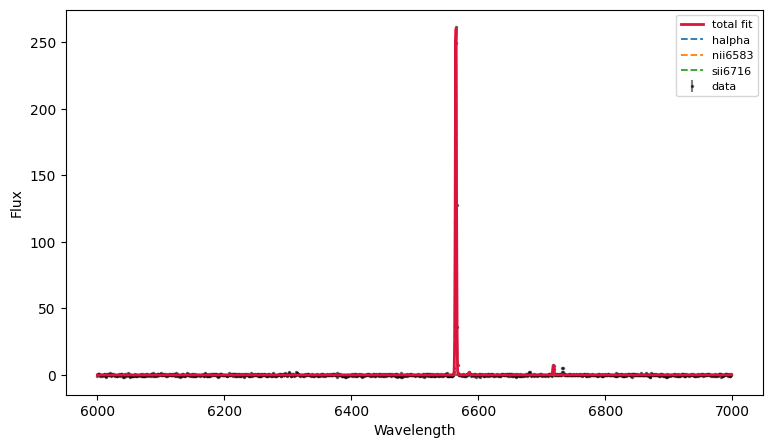

In [67]:
result.plot_fit()

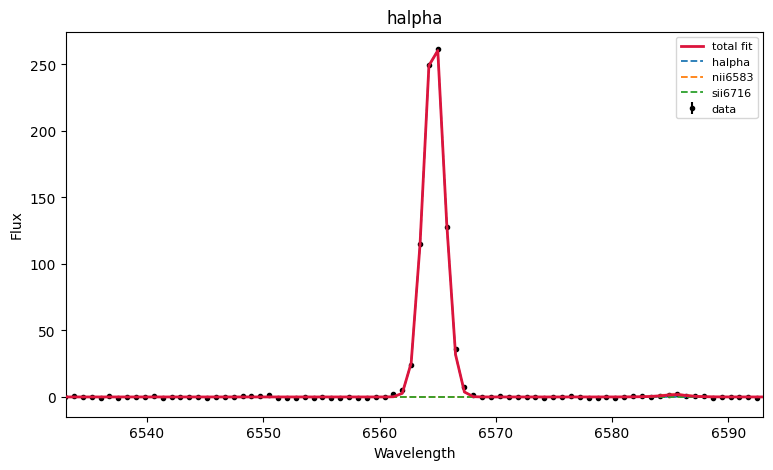

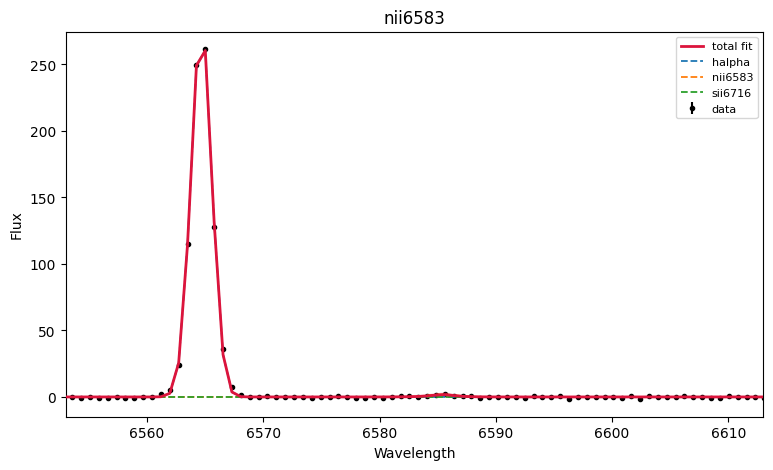

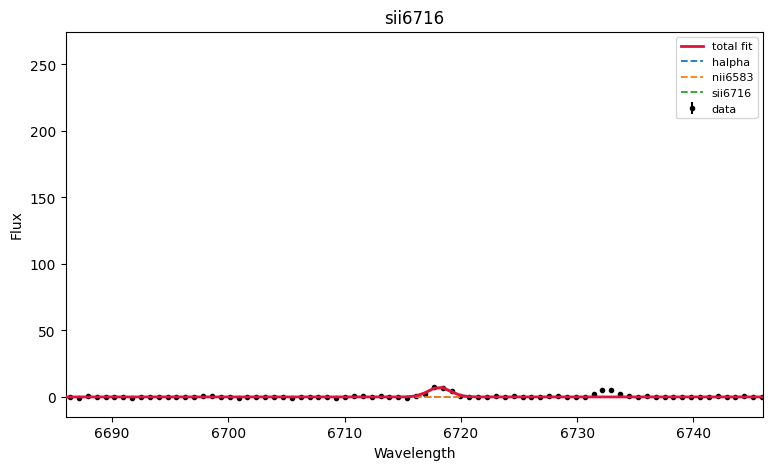

In [73]:
for line, label in zip(line_centers, line_names):
    result.plot_fit()
    plt.xlim(line - 30, line+30)
    plt.title(label)
    

In [78]:
result.summary()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
amp[0],279.415,0.506,278.520,280.391,0.012,0.011,1672.0,1250.0,1.00
amp[1],1.934,0.730,0.735,3.233,0.055,0.085,356.0,111.0,1.01
amp[2],7.379,0.515,6.431,8.362,0.017,0.010,915.0,898.0,1.00
mu[0],6564.677,0.002,6564.673,6564.681,0.000,0.000,1639.0,1234.0,1.00
mu[1],6585.364,0.411,6584.610,6586.126,0.012,0.021,1488.0,983.0,1.00
mu[2],6718.146,0.078,6717.999,6718.295,0.001,0.003,2970.0,1373.0,1.00
sigma[0],0.893,0.002,0.890,0.897,0.000,0.000,1200.0,1262.0,1.00
sigma[1],1.146,0.539,0.300,2.073,0.023,0.015,361.0,108.0,1.01
sigma[2],0.939,0.072,0.802,1.070,0.002,0.002,1514.0,1392.0,1.00
c0,0.010,0.017,-0.019,0.044,0.001,0.000,1017.0,685.0,1.00


In [79]:
result.line_fluxes()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
integrated_flux[halpha],625.646,1.143,623.311,627.664,0.023,0.040,2299.0,1165.0,1.0
integrated_flux[nii6583],4.869,1.477,2.183,7.670,0.047,0.032,922.0,909.0,1.0
integrated_flux[sii6716],17.313,1.164,15.197,19.549,0.036,0.026,1046.0,1336.0,1.0


In [46]:
print_results(fits)

6564.7	655.7297 erg / (s cm2)
6573.0	  0.0000 erg / (s cm2)
6718.1	 18.2996 erg / (s cm2)


In [51]:
meas["halpha_cont"]

1.543965985720093

In [91]:
625.646 * meas["flux_scale"] / (1 + z)

730.20433100239

In [269]:
meas["halpha_center"], meas["halpha_flux"], meas["halpha_fluxerr"]

(6564.692153213563, 718.646819762877, 9.59951552779172)

In [87]:
17.313 * meas["flux_scale"] / (1 + z)

20.206358839734254

In [270]:
meas["sii6716_flux"], meas["sii6716_center"]

(20.31448792685156, 6718.158475041158)

In [93]:
4.869 * meas["flux_scale"] / (1+z)

5.682710171008265

In [92]:
meas["nii6583_flux"], meas["nii6583_center"]

(5.636329996409138, 6585.555520111693)

### Oxygen lines

In [148]:
region = (4700, 4800, 5050, 5150)

In [149]:
subspec = contsub(flat_spec, *region)

In [150]:
line_windows = [(4861-10, 4861+10), (4959-10, 4959+10), (5007-10, 5007+10)]

In [151]:
fits = fit_all_lines(subspec, line_windows)

Model: Gaussian1D
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
          amplitude               mean             stddev      
    erg / (Angstrom s cm2)      Angstrom          Angstrom     
    ---------------------- ----------------- ------------------
    1.5529861551592783e-16 4861.894831008914 2.7624408123043542
Model: Gaussian1D
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
          amplitude               mean             stddev      
    erg / (Angstrom s cm2)      Angstrom          Angstrom     
    ---------------------- ----------------- ------------------
    3.0380742125622265e-16 4960.293722857402 1.3579501987811413
Model: Gaussian1D
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
          amplitude               mean             stddev      
    erg / (Angstrom s cm2)      Angstrom          Angstrom     
    ---------------------- ----------------- ------------------
    1.0846113106634047e-15 5008.247343730089 0.833400709543

In [152]:
fits

[<Gaussian1D(amplitude=0. erg / (Angstrom s cm2), mean=4862.66023483 Angstrom, stddev=0.57380456 Angstrom)>,
 <Gaussian1D(amplitude=0. erg / (Angstrom s cm2), mean=4960.29985505 Angstrom, stddev=0.58654688 Angstrom)>,
 <Gaussian1D(amplitude=0. erg / (Angstrom s cm2), mean=5008.21736224 Angstrom, stddev=0.53515321 Angstrom)>]

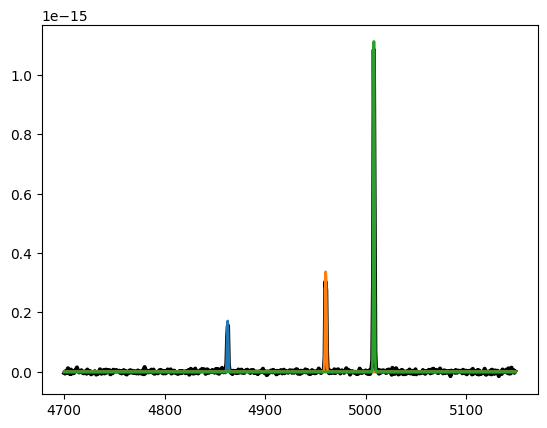

In [153]:
plot_line_models(subspec, fits)


In [154]:
print_results(fits)

4862.7	 26.6070 erg / (s cm2)
4960.3	 56.1156 erg / (s cm2)
5008.2	161.5516 erg / (s cm2)


In [155]:
good_lines

['oii3726',
 'oii3729',
 'neiii3869',
 'hdelta',
 'hgamma',
 'oiii4363',
 'hbeta',
 'oiii4959',
 'oiii5007',
 'hei5876',
 'halpha',
 'sii6716',
 'sii6731',
 'ariii7136']

In [156]:
meas["hbeta_center"], meas["hbeta_flux"]

(4862.643326836453, 28.54783811025737)

In [157]:
meas["oiii4959_center"], meas["oiii4959_flux"]

(4960.320240580186, 58.96679898359561)

In [158]:
meas["oiii5007_center"], meas["oiii5007_flux"], meas["oiii5007_fluxerr"]

(5008.221428841062, 170.2860419445776, 6.069676913491587)

In [159]:
good_lines

['oii3726',
 'oii3729',
 'neiii3869',
 'hdelta',
 'hgamma',
 'oiii4363',
 'hbeta',
 'oiii4959',
 'oiii5007',
 'hei5876',
 'halpha',
 'sii6716',
 'sii6731',
 'ariii7136']

## Hgamma

# OII

In [94]:
region = (3600, 3700, 3770, 3860)

In [95]:
subspec = contsub(flat_spec, *region)

In [96]:
line_centers = [3726, 3729]
line_names = ["oiii3726", "oiii3729"]

In [100]:
result = fit_lines(
    subspec.spectral_axis, subspec.flux * 1e17, None,
    line_centers=line_centers,
    line_names=line_names,
    draws=1000, tune=1000, chains=2,  
    fit_continuum=True,
)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [amp, mu, sigma_raw, c0, c1, noise]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 7 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


(3700.0, 3750.0)

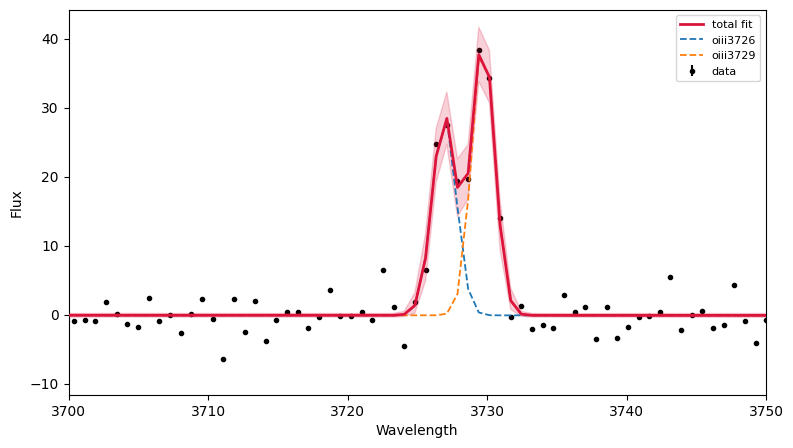

In [101]:
result.plot_fit()
plt.xlim(3700, 3750)

In [102]:
result.line_fluxes()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
integrated_flux[oiii3726],61.876,5.940,50.718,73.174,0.151,0.114,1552.0,1277.0,1.0
integrated_flux[oiii3729],81.863,5.794,69.835,91.591,0.141,0.109,1683.0,1556.0,1.0


In [108]:
meas["oii3726_center"], meas["oii3726_flux"] / meas["flux_scale"], meas["oii3726_fluxerr"] / meas["flux_scale"]

(3726.928455972743, 64.48612438887477, 10.62293436786844)

In [110]:
meas["oii3729_center"], meas["oii3729_flux"] / meas["flux_scale"] , meas["oii3729_fluxerr"] / meas["flux_scale"]

(3729.727702796047, 85.46589317557844, 11.324285772703975)